In [1]:
# from scipy.fft import fftn, irfft, irfftn, rfft, rfftn
from time import time
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = str(-1)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from jax import config, jit
from jax.numpy.fft import fft, fftn, irfft, irfftn, rfft, rfftn, ifftn
from matplotlib.colors import LogNorm
from PIL import Image

from l3es.init_fields import init_u_hit
from l3es.visualize import plot_views
from l3es.turbulence import mls_2nd_order

config.update("jax_enable_x64", True)


In [ ]:
def dft1d(y_x, x_axis, L, dtype=np.complex128):
    """Discrete Fourier Transform of a 1D signal."""
    N = len(y_x)
    k = np.fft.fftfreq(N, 1/N)  # array of frequency indices
    y_k = np.zeros_like(k, dtype=dtype)
    for i, k_i in enumerate(k):
        # k*n/N -> k*x_i/L
        y_k[i] = np.sum(y_x * np.exp(-2j * np.pi * k_i * x_axis / L))
    return y_k  # complex valued

def idft1d(y_k, x_axis, L):
    """Inverse Discrete Fourier Transform of a 1D signal."""
    N = len(y_k)
    k = np.fft.fftfreq(N, 1/N)  # array of frequency indices
    y_x = np.zeros_like(x_axis)
    for i, x_i in enumerate(x_axis):
        # k*n/N -> k*x_i/L
        y_x[i] = np.real(np.sum(y_k * np.exp(2j * np.pi * k * x_i / L)))/N
    return y_x  # real valued


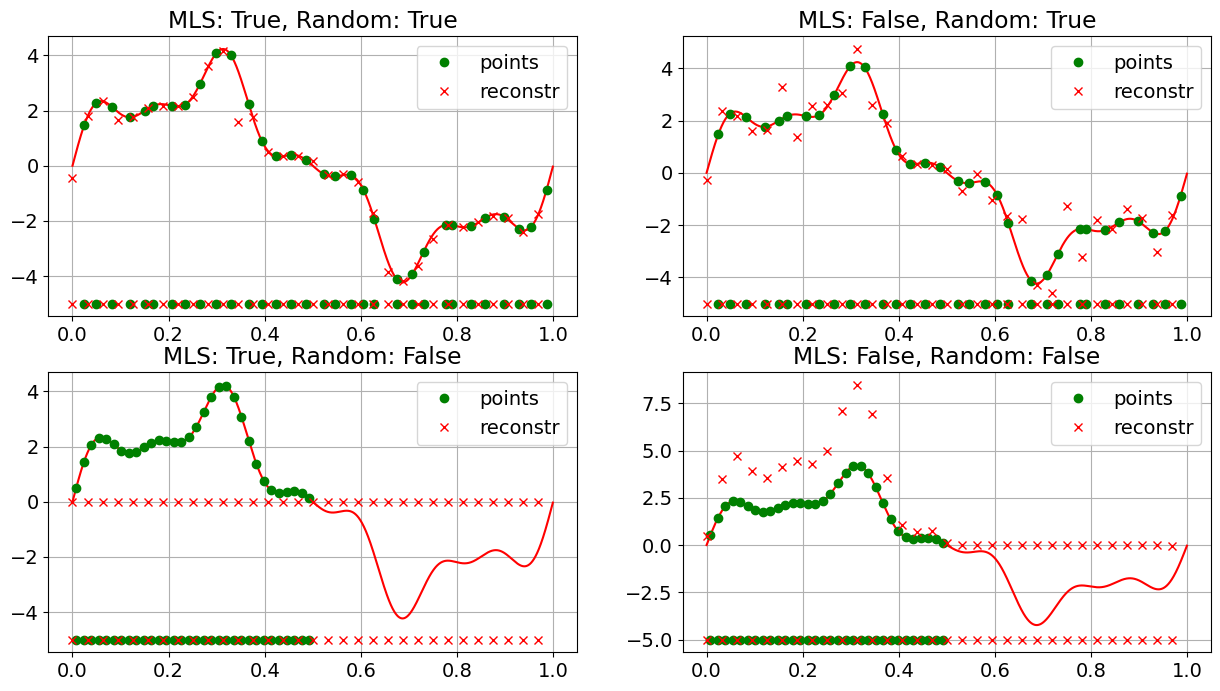

In [26]:
# number of points
N = 32
L = 1  # code currently works only for L=1

# signal
def f(t):
    return 3*np.sin(2*np.pi*t) + np.sin(2*np.pi*4*t) + 0.5*np.sin(2*np.pi*7*t)

# sample signal on fine regular grid
ts = 1.0/2000
t = np.arange(0,1,ts)  
y = f(t)

fig, axs = plt.subplots(2, 2, figsize=(15,8))

for ax, is_mls, is_rand in zip(axs.flatten(), [True, False, True, False], [True, True, False, False]):
    if is_rand:
        # sample signal on coarse irregular grid
        np.random.seed(0)
        r_p = np.array((np.arange(N)/N + 1/N/2 + np.random.randn(N)/200))%1
        y_p = f(r_p)
        # interpolate from irregular grid with N points to regular grid with N points
        r_interp = np.linspace(0, L, N, endpoint=False)[:,None]
        if is_mls:
            y_interp = mls_2nd_order(r_p, r_interp, y_p, 1, 1/N, 1, kernel_name="M4PrimeKernel")
        else:
            y_r_dft = dft1d(y_p, r_p, L)
            y_interp = np.real(np.fft.ifft(y_r_dft))
    else:
        # from squeezed regular grid to normal grid
        r_p = np.array((np.arange(N)/N/2 + 1/N/2/2))%1
        y_p = f(r_p)
        if is_mls:
            # y_interp = mls_2nd_order(r_p, r_interp, y_p, 1, 1/N, 1, kernel_name="M4PrimeKernel")
            y_interp = np.zeros_like(r_interp)
        else:
            y_r_dft = dft1d(y_p, r_p, L)
            y_interp = np.real(np.fft.ifft(y_r_dft))

    # plot
    ax.plot(t, y, "r")
    ax.plot(r_p, y_p, 'og', label='points')
    ax.plot(r_interp, y_interp, "xr", label='reconstr')
    # show distances along x-axis
    ax.plot(r_p, np.ones_like(r_p)*(-5), 'og')
    ax.plot(r_interp, np.ones_like(r_interp)*(-5), 'xr')
    ax.set_title(f"MLS: {is_mls}, Random: {is_rand}")
    ax.grid()
    ax.legend()

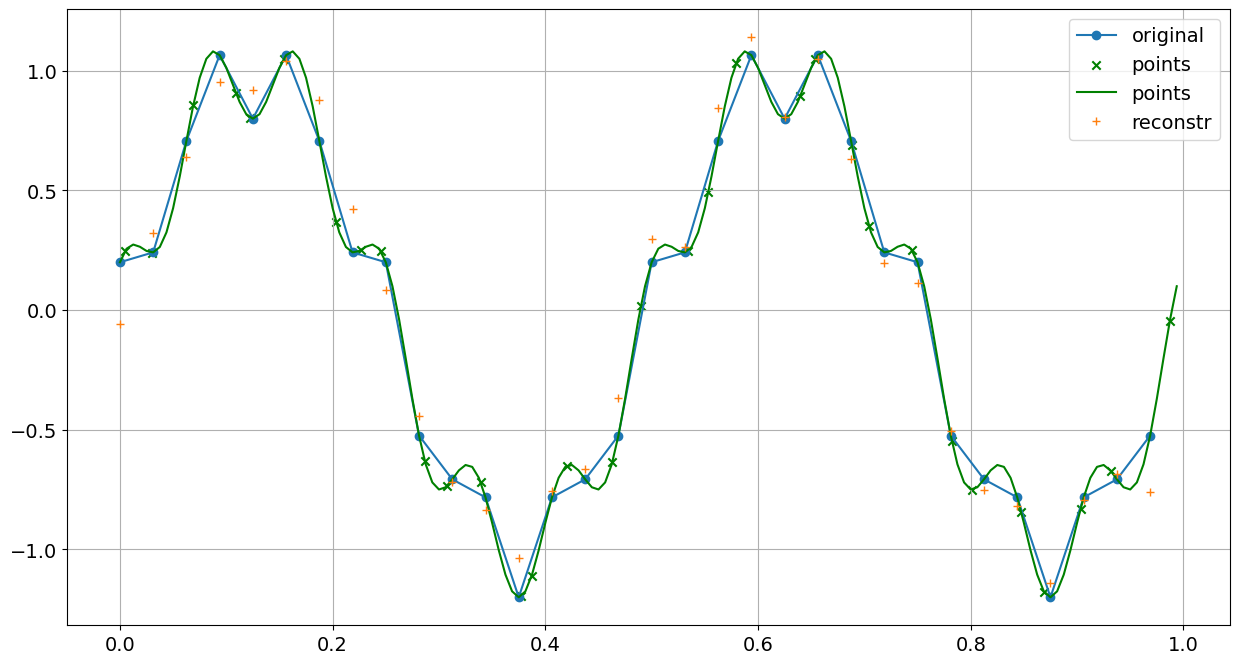

In [19]:
# 1D Grid - particles - grid
is_my_dft = False
is_mls = True

dtype_real = np.float64
dtype_complex = np.complex128
N = 32 # Number of sample points
L = 1.0  # Length of signal domain
dx = L / N  # assuming the signal is sampled at dx units
k = np.array(np.fft.fftfreq(N, 1/N), dtype=dtype_complex)
x_grid = np.linspace(0.0, L, N, endpoint=False, dtype=dtype_real)  # (N,)
# Generate signal in the physical domain
y_grid = np.sin(2.0 * 2.0*np.pi*x_grid) + 0.2*np.cos(20 * 2.0*np.pi*x_grid)  # (N,)
# Random coordinates r
np.random.seed(42)
r = np.array((np.arange(N)/N + np.random.randn(N)/100)%L, dtype=dtype_real)


### For the grid->particles interpolation, the DFT interpolation does what we want.
if False:  # is_mls
    # MLS code here
    dim = 2
    box_size = L * np.ones(dim)
    
    x_grid_mls = (np.array(np.meshgrid(x_grid, x_grid, indexing="ij")).T).reshape(-1, 2)  # (N**2, 2)
    r_mls = (np.array(np.meshgrid(r, r, indexing="ij")).T).reshape(-1, 2)  # (N**2, 2)
    y_grid_mls = np.tile(y_grid, N)  # (N**2,)

    # interpolate velocities to sph particles
    y_r = mls_2nd_order(r=x_grid_mls, r_target=r_mls, f=y_grid_mls, box_size=box_size, dx=dx, dim=dim)
    y_r = np.array(y_r)
else:
    # Transform signal to Fourier space
    y_fft = dft1d(y_grid, x_grid, L) if is_my_dft else np.fft.fft(y_grid)

    # Compute direct inverse Fourier transform
    y_r = idft1d(y_fft, r, L)

### For the particles->grid interpolation, we need to use MLS and also to make sure particles are 
# well distributed. See Eq. (8) in Shi et al. 2013.
if True:  # is_mls
    # MLS code here
    dim = 2
    box_size = L * np.ones(dim)
    
    x_grid_mls = (np.array(np.meshgrid(x_grid, x_grid, indexing="ij")).T).reshape(-1, 2)  # (N**2, 2)
    r_mls = (np.array(np.meshgrid(r, r, indexing="ij")).T).reshape(-1, 2)  # (N**2, 2)
    y_grid_mls = np.tile(y_grid, N)  # (N**2,)

    # interpolate velocities to grid
    y_grid_ = mls_2nd_order(r=r_mls, r_target=x_grid_mls, f=y_grid_mls, box_size=box_size, dx=dx, dim=dim)
    y_r = y_r[:N]
    y_grid_ = np.array(y_grid_[:N])
else:
    # Compute back spectrum from signal on points r
    y_r_dft = np.zeros_like(k)
    for i, k_i in enumerate(k):
        y_r_dft[i] = np.sum(y_r * np.exp(-2j * np.pi * k_i * r / L))

    # Reconstruct signal on the grid
    if is_my_dft:
        y_grid_ = np.zeros_like(y_grid)
        for i, x_i in enumerate(x_grid):
            y_grid_[i] = np.real(np.sum(y_r_dft * np.exp(2j * np.pi * k * x_i / L))) / N
    else:
        y_grid_ = np.real(np.fft.ifft(y_r_dft))

hq_factor = 5
N_hq = hq_factor*N
x_grid_hq = np.linspace(0.0, L, N_hq, endpoint=False, dtype=dtype_real)  # (N,)
temp = np.zeros((N_hq-N)//2, dtype=dtype_complex)
y_fft_hq = np.fft.fftshift(np.concat([temp, np.fft.fftshift(y_fft), temp])) / (1/hq_factor)
y_grid_hq = np.fft.ifft(y_fft_hq).real

# y_r_dft_hq = np.fft.fftshift(np.concat([temp, np.fft.fftshift(y_r_dft), temp])) / (1/hq_factor)
# y_r_dft_hq = np.fft.ifft(y_r_dft_hq).real

plt.figure(figsize=(15,8))
plt.plot(x_grid, y_grid, marker="o", label='original')
plt.scatter(r, y_r, c='g', marker="x", label='points')
plt.plot(x_grid_hq, y_grid_hq, "g", label='points')
plt.plot(x_grid, y_grid_, "+", c="tab:orange", label='reconstr')
# plt.plot(x_grid_hq, y_r_dft_hq, c="tab:orange", label='reconstr')
plt.legend()
plt.grid()
plt.show()

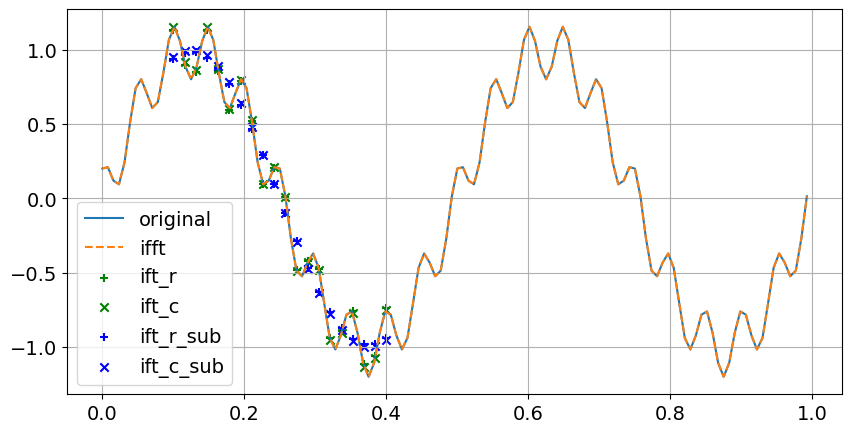

In [12]:
# 1D
N = 128 # Number of sample points
L = 1.0  # Length of signal domain
dx = L / N  # assuming the signal is sampled at dx units
x_grid = np.linspace(0.0, L, N, endpoint=False)
# Generate signal in the physical domain
y_grid = np.sin(2.0 * 2.0*np.pi*x_grid) + 0.2*np.cos(20 * 2.0*np.pi*x_grid)

# Transform signal to Fourier space and back
y_rfft = rfft(y_grid)
y_fft = fft(y_grid)
y_irfft = irfft(y_rfft)

# Work with arbitrary position x
arbitrary_x = np.linspace(0.1, 0.4, 20)

# Compute direct inverse Fourier transform
k_r = np.fft.rfftfreq(N, 1/N)  #np.arange(N//2+1)  # array of frequency indices
k = np.fft.fftfreq(N, 1/N)  #  # array of frequency indices
arbitrary_y = np.zeros_like(arbitrary_x)
y_temp = np.zeros_like(arbitrary_x)
for i, x_i in enumerate(arbitrary_x):
    # k*n/N -> k*x_i/L
    arbitrary_y[i] = np.real(np.sum(y_rfft * np.exp(2j * np.pi * k_r * x_i / L))/len(y_rfft))
    y_temp[i] = np.real(np.sum(y_fft * np.exp(2j * np.pi * k * x_i / L))/len(y_fft))

# Spectral filtering while reconstructing the signal
N_sub = 10
k_r_sub = np.fft.rfftfreq(N_sub, 1/N_sub)  #np.arange(N//2+1)  # array of frequency indices
k_sub = np.fft.fftfreq(N_sub, 1/N_sub)  #  # array of frequency indices
y_rfft_sub = y_rfft[:N_sub//2+1]
y_fft_sub = np.concat([y_fft[:N_sub//2], y_fft[-N_sub//2:]])
arbitrary_y_sub = np.zeros_like(arbitrary_x)
y_temp_sub = np.zeros_like(arbitrary_x)
# print(k_r_sub.shape, y_rfft_sub.shape, k_sub.shape, y_fft_sub.shape)
for i, x_i in enumerate(arbitrary_x):
    # k*n/N -> k*x_i/L
    arbitrary_y_sub[i] = np.real(np.sum(y_rfft_sub * np.exp(2j * np.pi * k_r_sub * x_i / L))/len(y_rfft))
    y_temp_sub[i] = np.real(np.sum(y_fft_sub * np.exp(2j * np.pi * k_sub * x_i / L))/len(y_fft))

plt.figure(figsize=(10,5))
plt.plot(x_grid, y_grid, label='original')
plt.plot(x_grid, y_irfft, "--", label='ifft')
plt.scatter(arbitrary_x, arbitrary_y, c='g', marker="+", label='ift_r')
plt.scatter(arbitrary_x, y_temp, c="g", marker="x", label='ift_c')
plt.scatter(arbitrary_x, arbitrary_y_sub, c='b', marker="+", label='ift_r_sub')
plt.scatter(arbitrary_x, y_temp_sub, c="b", marker="x", label='ift_c_sub')
plt.legend()
plt.grid()
plt.show()


In [136]:
y = np.random.rand(32,32)
N_sub = 6
sl = slice(len(y)//2 - N_sub//2, len(y)//2 + N_sub//2)
y_fft_sub = np.fft.fftshift(np.fft.fftfreq(len(y), 1/len(y)))[sl]

np.fft.fftshift(np.fft.fftfreq(N_sub, 1/N_sub)), y_fft_sub

(array([-3., -2., -1.,  0.,  1.,  2.]), array([-3., -2., -1.,  0.,  1.,  2.]))

In [4]:
np.fft.rfftfreq(10)*10, np.fft.fftfreq(10)*10

(array([0., 1., 2., 3., 4., 5.]),
 array([ 0.,  1.,  2.,  3.,  4., -5., -4., -3., -2., -1.]))

In [29]:
np.fft.fftshift(np.fft.rfftfreq(10)*10), np.fft.fftshift(np.fft.fftfreq(10)*10)

(array([3., 4., 5., 0., 1., 2.]),
 array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.]))

In [11]:
np.fft.fftshift(np.fft.fftshift(np.fft.rfftfreq(10)*10)), np.fft.fftshift(np.fft.fftshift(np.fft.fftfreq(10)*10))

(array([0., 1., 2., 3., 4., 5.]),
 array([ 0.,  1.,  2.,  3.,  4., -5., -4., -3., -2., -1.]))

In [57]:
# Create a real-valued signal
x = np.linspace(0, 1, 100)
# Compute the rFFT of the signal
x_rfft = np.fft.rfft(x)
# Compute the FFT of the signal
x_fft = np.fft.fft(x)
# To compare, let's reconstruct the FFT from the rFFT result
n = x.size
x_rfft_full = np.concatenate((x_rfft, x_rfft[-2:0:-1].conj()))
np.isclose(x_fft, x_rfft_full)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

[[ True  True  True ...  True  True  True]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 ...
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]
 [ True  True  True ... False False False]]
#1 [[-2.65742983e-12+0.00000000e+00j -2.53928571e+02+4.50042001e+02j
  -6.94626293e+01+3.30006473e+02j ... -7.62326073e+01-1.99512392e+02j
  -6.94626293e+01-3.30006473e+02j -2.53928571e+02-4.50042001e+02j]
 [ 5.04448025e-01-2.08794498e+01j  2.07661908e+01-1.52632259e+01j
   1.54560388e+01-2.00271718e+01j ...  3.35752333e+00+7.23689942e+00j
   3.43451757e-01+1.77656114e+01j  2.01750613e+01-2.78559467e+00j]
 [-5.15679545e+00-1.24865320e+01j  1.29147378e+00+5.38509174e+00j
   2.59851881e+00+6.27337934e+00j ... -5.64024800e+00-1.06573082e+00j
  -1.44043100e+01+9.60287336e+00j  9.59097244e+00+1.20832039e-01j]
 ...
 [ 1.66522741e-01+1.10202401e+01j  1.04940268e+01-3.44363280e+00j
  -1.06116024e+01-6.97961044e+00j ... -4.65653654e+00

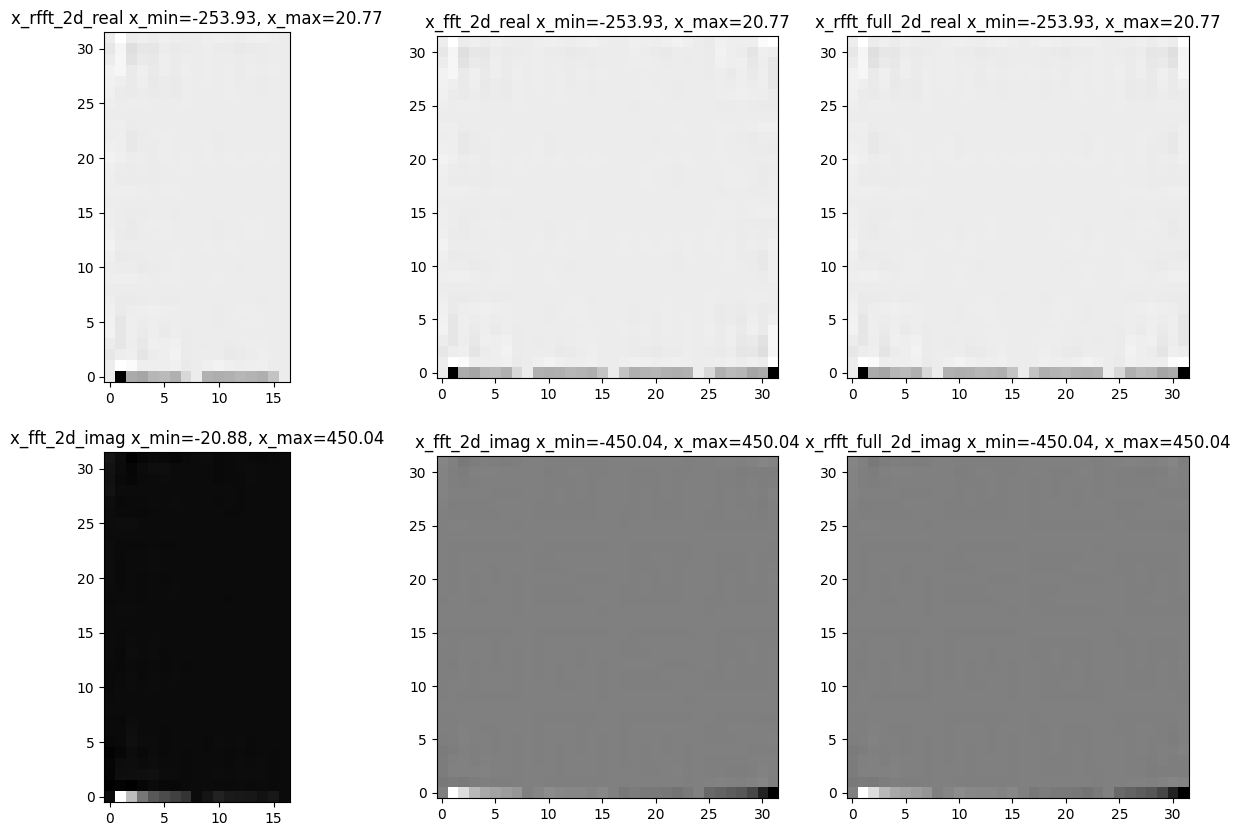

In [99]:
# Create a 2D real-valued signal
x_2d = y[32:64, :32]-0.5  #np.linspace(0, 1, 100).reshape(10, 10)
x_2d = x_2d - x_2d.mean()
x_2d = x_2d / x_2d.std()

# Compute the 2D rFFT of the signal
x_rfft_2d = np.fft.rfft2(x_2d)

# Compute the 2D FFT of the signal
x_fft_2d = np.fft.fft2(x_2d)

# To compare, let's reconstruct the 2D FFT from the 2D rFFT result
n, m = x_2d.shape
x_rfft_full_2d = np.concatenate((x_rfft_2d, x_rfft_2d[:, -2:0:-1].conj()), axis=1)

# Compare the original 2D FFT with the reconstructed 2D FFT
comparison_result = np.isclose(x_fft_2d, x_rfft_full_2d)

print(comparison_result)
print("#1", x_fft_2d)
print("#2", x_rfft_full_2d)
def plt_ax(ax, x, title):
    ax.imshow(x, cmap='gray', origin='lower')
    ax.set_title(f"{title} x_min={x.min():.2f}, x_max={x.max():.2f}")
    
fig, ax = plt.subplots(2,3, figsize=(15, 10))
plt_ax(ax[0,0], x_rfft_2d.real, "x_rfft_2d_real")
plt_ax(ax[1,0], x_rfft_2d.imag, "x_fft_2d_imag")
plt_ax(ax[0,1], x_fft_2d.real, "x_fft_2d_real")
plt_ax(ax[1,1], x_fft_2d.imag, "x_fft_2d_imag")
plt_ax(ax[0,2], x_rfft_full_2d.real, "x_rfft_full_2d_real")
plt_ax(ax[1,2], x_rfft_full_2d.imag, "x_rfft_full_2d_imag")

In [42]:
a = np.linspace(0, 10, 10, endpoint=False)
a_fft = np.fft.fft(a)
a_rfft = np.fft.rfft(a)
a_fft, a_rfft

(array([45. +0.j        , -5.+15.38841769j, -5. +6.8819096j ,
        -5. +3.63271264j, -5. +1.62459848j, -5. +0.j        ,
        -5. -1.62459848j, -5. -3.63271264j, -5. -6.8819096j ,
        -5.-15.38841769j]),
 array([45. +0.j        , -5.+15.38841769j, -5. +6.8819096j ,
        -5. +3.63271264j, -5. +1.62459848j, -5. +0.j        ]))

(2, 32, 32) (65536, 2) (32, 32)


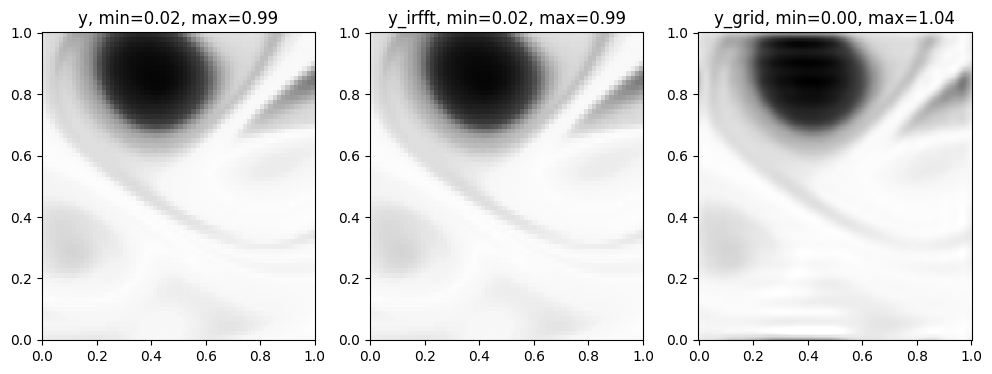

In [137]:
# 2D

im_frame = Image.open("2Dturb.png")
np_frame = np.array(im_frame)
y = np_frame[100:356,100:356,0]/255  # (256,256)

N = len(y)  # 256
L = 1.0
dx = L / N
X1, X2 = np.meshgrid(np.linspace(0, L, N), np.linspace(0, L, N), indexing="ij")

np.random.seed(0)
# arbitrary_x = np.random.uniform(0.0, 1.0, size=(500,2))
arbitrary_x = np.stack(np.meshgrid(np.linspace(0.05,0.95,20), np.linspace(0,1,20))).reshape(2,400).T
grid_x = np.stack([X1.ravel(), X2.ravel()], axis=1)

y_rfft = rfftn(y, axes=(1,0))  # (129, 256)
y_fft = fftn(y, axes=(1,0))  # (256, 256)
y_irfft = irfftn(y_rfft, axes=(1,0))  # (256, 256)

# reconstruct at arbitrary positions
# k = np.fft.fftfreq(N, 1./N) # for y and z direction
# kx = np.fft.rfftfreq(N, 1./N) # for x direction
# k_field = np.array(np.meshgrid(kx, k, indexing="ij"), dtype=int)
# arbitrary_y = np.zeros_like(arbitrary_x[:,0])
# for i, x_i in enumerate(arbitrary_x):
#     exponential = np.exp(2j * np.pi * (k_field[0] * x_i[0] / L + k_field[1] * x_i[1] / L))
#     arbitrary_y[i] = np.real(np.sum(y_rfft / N**2 * exponential))
##################


# Spectral filtering while reconstructing the signal
N_sub = 32 # frequency channels to keep

is_complex = True
if is_complex:
    k = np.fft.fftshift(np.fft.fftfreq(N_sub, 1./N_sub)) # put 0 in the middle
    k_field = np.array(np.meshgrid(k, k, indexing="ij"), dtype=int)
    sl = slice(len(y)//2 - N_sub//2, len(y)//2 + N_sub//2)
    y_fft_sub = np.fft.fftshift(y_fft, axes=(0,1))[sl, sl]    
    grid_y = np.zeros_like(grid_x[:,0])
    print(k_field.shape, grid_x.shape, y_fft_sub.shape)
    for i, x_i in enumerate(grid_x):
        exponential = np.exp(2j * np.pi * (k_field[0] * x_i[0] / L + k_field[1] * x_i[1] / L))
        grid_y[i] = np.real(np.sum(y_fft_sub / N**2 * exponential))
else
    raise NotImplementedError("Couldn't get it to work")
    # y_fft_sub = np.concatenate((y_rfft, y_rfft[-2:0:-1].conj()), axis=0)
    # k = np.fft.fftfreq(N_sub, 1./N_sub) # for y and z direction
    # k_field = np.array(np.meshgrid(k, k, indexing="ij"), dtype=int)
    # y_fft_sub = np.concat([y_fft_sub[:N_sub//2], y_fft_sub[-N_sub//2:]], axis=0)
    # y_fft_sub = np.concat([y_fft_sub[:, :N_sub//2], y_fft_sub[:, -N_sub//2:]], axis=1)
    # grid_y = np.zeros_like(grid_x[:,0])
    # print(k_field.shape, grid_x.shape, y_fft_sub.shape)
    # for i, x_i in enumerate(grid_x):
    #     exponential = np.exp(2j * np.pi * (k_field[0] * x_i[0] / L + k_field[1] * x_i[1] / L))
    #     grid_y[i] = np.real(np.sum(y_fft_sub / N**2 * exponential))

    kx = np.fft.rfftfreq(N_sub, 1./N_sub) # for x direction
    k = np.fft.fftfreq(N_sub, 1./N_sub) # for y and z direction
    k_field = np.array(np.meshgrid(kx, k, indexing="ij"), dtype=int)
    y_rfft_sub = y_rfft[:N_sub//2+1]
    y_rfft_sub = np.concat([y_rfft_sub[:, :N_sub//2], y_rfft_sub[:, -N_sub//2:]], axis=1)
    grid_y = np.zeros_like(grid_x[:,0])
    print(k_field.shape, grid_x.shape, y_rfft_sub.shape)
    for i, x_i in enumerate(grid_x):
        exponential = np.exp(2j * np.pi * (k_field[0] * x_i[0] / L + k_field[1] * x_i[1] / L))
        grid_y[i] = np.real(np.sum(y_rfft_sub / N**2 * exponential))

grid_y = grid_y.reshape(N,N)


##################

fig, ax = plt.subplots(1,3, figsize=(12,4))
# ax[0].imshow(y, cmap='gray', origin='lower')
# ax[1].imshow(y_irfft, cmap='gray')
ax[0].pcolormesh(X1, X2, y, cmap='gray', vmin=0.0, vmax=1.0)
ax[0].set_title(f"y, min={y.min():.2f}, max={y.max():.2f}")
ax[1].pcolormesh(X1, X2, y_irfft, cmap='gray', vmin=0.0, vmax=1.0)
ax[1].set_title(f"y_irfft, min={y_irfft.min():.2f}, max={y_irfft.max():.2f}")
ax[2].pcolormesh(X1, X2, grid_y, cmap='gray', vmin=0.0, vmax=1.0)
ax[2].set_title(f"y_grid, min={grid_y.min():.2f}, max={grid_y.max():.2f}")
# sl = slice(None,None)
# ax[1].pcolormesh(X1[sl,sl], X2[sl,sl], y_irfft[sl,sl], cmap='gray')
# ax[1].set_title(f"min={y_irfft[sl,sl].min():.2f}, max={y_irfft[sl,sl].max():.2f}")

# y_rfft_abs = np.abs(_y_fft)
# ax[0].set_title(f"min={y_rfft_abs.min():.1f}, max={y_rfft_abs.max():.1f}")
# ax[0].imshow(y_rfft_abs, cmap='gray', norm=LogNorm(vmin=0.1))
# ax[0].spy(y_rfft_abs)

# ax[2].scatter(arbitrary_x[:,0], arbitrary_x[:,1], c=arbitrary_y, cmap='gray')
# ax[2].set_title(f"min={arbitrary_y.min():.2f}, max={arbitrary_y.max():.2f}")
# ax[2].set_xlim(0,1); ax[2].set_ylim(0,1)
plt.show()

#1 (33, 64, 64) (64, 64, 64) (64, 64, 64)
#2 (3, 16, 16, 16) (12097, 3) (16, 16, 16)
0.5140721797943115


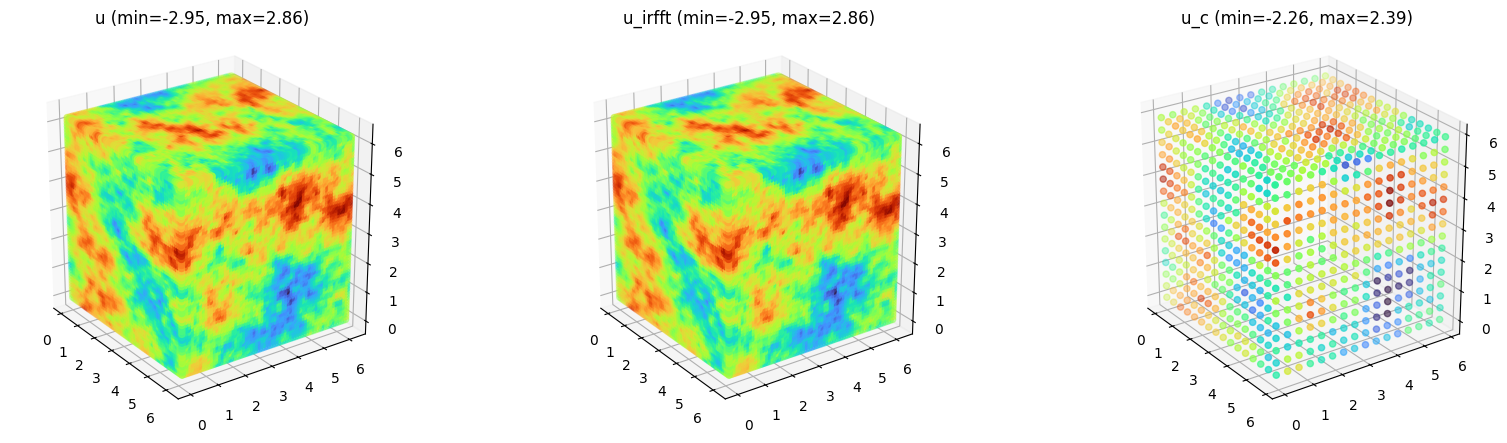

In [3]:
# 3D
def plot_view(grid_x_s, us, labels = ["u", "u_irfft", "u_c",]):

    def subplot_i(fig, ind, c, lbl, grid):
        ax = fig.add_subplot(1, 3, ind, projection="3d")
        ax.view_init(elev=25.0, azim=-35, roll=0)
        ax.scatter(grid[:,0], grid[:,1], grid[:,2], c=c, cmap="turbo")
        ax.set_aspect("equal", "box")
        ax.set_title(f"{lbl} (min={c.min():.2f}, max={c.max():.2f})")

    # plot results
    fig = plt.figure(figsize=(20, 5))
    for i, (c, lbl, grid) in enumerate(zip(us, labels, grid_x_s)):
        subplot_i(fig, i + 1, c, lbl, grid)

def gen_surf_grid(N = 64, L=2*np.pi):
    dx = L / N
    X_, Y_, Z_ = np.mgrid[:N, :N, :N].astype(float) * 2 * np.pi / N  # (3,N,N,N)
    mask = (X_ > 2 * np.pi - 1.5 * dx) + (Y_ < 0.5 * dx) + (Z_ > 2 * np.pi - 1.5 * dx)
    grid_x = np.stack([X_[mask], Y_[mask], Z_[mask]], axis=1)  # (12097, 3)
    return grid_x, mask


N = 64
L = 2*np.pi
dx = L / N
grid_x, mask = gen_surf_grid(N=N)

y = init_u_hit(N)[0]  # (N,N,N)

y_rfft = rfftn(y, axes=(2, 1,0))  # (33, 64, 64)
y_fft = fftn(y, axes=(2,1,0))  # (64, 64, 64)
y_irfft = irfftn(y_rfft, axes=(2,1,0))  # (64, 64, 64)
print("#1", y_rfft.shape, y_fft.shape, y_irfft.shape)


# Spectral filtering while reconstructing the signal
N_sub = 16 # frequency channels to keep
grid_x_coarse, mask_coarse = gen_surf_grid(N=N_sub)

k = np.fft.fftshift(np.fft.fftfreq(N_sub, 1./N_sub)) # for y and z direction
k_field = np.array(np.meshgrid(k, k, k, indexing="ij"), dtype=int)  # (3, 16, 16, 16)

sl = slice(len(y)//2 - N_sub//2, len(y)//2 + N_sub//2)
y_fft_sub = np.fft.fftshift(y_fft, axes=(0,1,2))[sl, sl, sl]  # (16, 16, 16)

# For some reason it doesn't work well with "rfft". Only with "fft"
# k = np.fft.fftshift(np.fft.fftfreq(N_sub, 1./N_sub)) # for y and z direction
# kx = np.fft.rfftfreq(N_sub, 1./N_sub)
# k_field = np.array(np.meshgrid(kx, k, k, indexing="ij"), dtype=int)  # (3, 9, 16, 16)
# sl = slice(len(y)//2 - N_sub//2, len(y)//2 + N_sub//2)
# y_fft_sub = np.fft.fftshift(y_rfft, axes=(1,2))[:N_sub//2+1, sl, sl]  # (9, 16, 16)
# print("#3", k_field.shape, y_fft_sub.shape)

grid_y = np.zeros_like(grid_x[:,0])
grid_y_coarse = np.zeros_like(grid_x_coarse[:,0])
print("#2", k_field.shape, grid_x.shape, y_fft_sub.shape)

def dft(x_i):
    exponential = jnp.exp(2j * jnp.pi * (k_field * x_i[:,None,None,None]).sum(axis=0) / L)
    res = jnp.real(jnp.sum(y_fft_sub / N**3 * exponential))
    return res

dft_fn = jit(dft)
a = dft_fn(jnp.ones(3))
a.block_until_ready()

t0 = time()
# for i, x_i in enumerate(jnp.array(grid_x)):
#     grid_y[i] = dft_fn(x_i)
for i, x_i in enumerate(jnp.array(grid_x_coarse)):
    grid_y_coarse[i] = dft_fn(x_i)
print(time() - t0)

# plot_view([grid_x]*3, [y[mask], y_irfft[mask], grid_y], ["u", "u_irfft", "u_c",])
plot_view([grid_x, grid_x, grid_x_coarse], [y[mask], y_irfft[mask], grid_y_coarse], ["u", "u_irfft", "u_c",])

In [12]:
a = np.fft.fftshift(y_rfft, axes=(1,2))
b = np.fft.ifftshift(a, axes=(1,2))
np.isclose(y_rfft, b).all(), y_rfft.shape

(np.True_, (33, 64, 64))

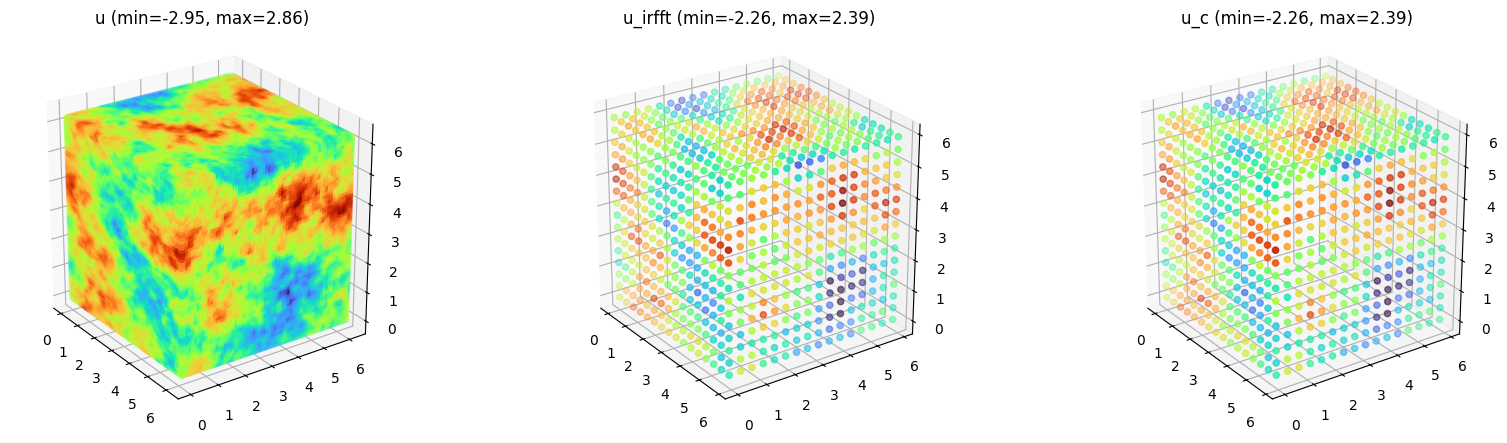

In [15]:
is_complexFFT = True
if is_complexFFT:
    sl = slice(len(y)//2 - N_sub//2, len(y)//2 + N_sub//2)
    y_fft_sub = np.fft.ifftshift(np.fft.fftshift(y_fft, axes=(0,1,2))[sl, sl, sl], axes=(0,1,2))  # (16, 16, 16)
    y_ifft = ifftn(y_fft_sub, axes=(2,1,0))/(N/N_sub)**3  # (64, 64, 64)
    y_ifft = y_ifft.real
    # print(y_fft.shape, y_fft_sub.shape, y_ifft.shape)
    plot_view([grid_x, grid_x_coarse, grid_x_coarse], [y[mask], y_ifft[mask_coarse], grid_y_coarse], ["u", "u_irfft", "u_c",])
else:  # real FFT
    # From (N//2+1,N,N) frequencies to (N_sub//2+1, N_sub, N_sub), and then iFFT to (N_sub, N_sub, N_sub) grid points
    sl_x = slice(0, N_sub//2+1)
    sl = slice(len(y)//2 - N_sub//2, len(y)//2 + N_sub//2)
    y_rfft_sub = np.fft.ifftshift(np.fft.fftshift(y_rfft, axes=(1,2))[sl_x, sl, sl], axes=(1,2))  # (9, 16, 16)
    y_irfft = irfftn(y_rfft_sub, axes=(2,1,0))/(N/N_sub)**3  # (64, 64, 64)
    # print(y_rfft.shape, y_rfft_sub.shape, y_irfft.shape)
    plot_view([grid_x, grid_x_coarse, grid_x_coarse], [y[mask], y_irfft[mask_coarse], grid_y_coarse], ["u", "u_irfft", "u_c",])


## Check spectral filtering when writing files

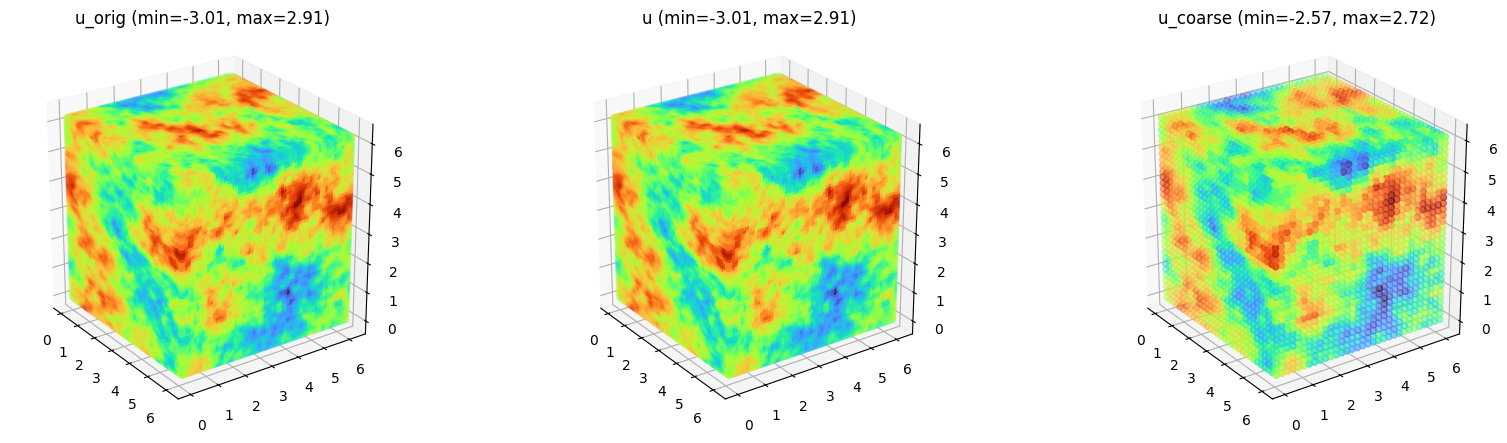

In [29]:
def gen_surf_grid(N = 64, L= 2*np.pi):
    dx = L / N
    X_, Y_, Z_ = np.mgrid[:N, :N, :N].astype(float) * 2 * np.pi / N  # (3,N,N,N)
    mask = (X_ > 2 * np.pi - 1.5 * dx) + (Y_ < 0.5 * dx) + (Z_ > 2 * np.pi - 1.5 * dx)
    grid_x = np.stack([X_[mask], Y_[mask], Z_[mask]], axis=1)  # (12097, 3)
    return grid_x, mask

grid_x, mask = gen_surf_grid(N=64)
grid_x_coarse, mask_coarse = gen_surf_grid(N=32)

files = ["u_64_00000_orig.npy", "u_64_00000.npy", "u_32_00000.npy"]
ys = [np.load(f"../results_hit/{file}")[0] for file in files]

plot_view(
    [grid_x, grid_x, grid_x_coarse], 
    [ys[0][mask], ys[1][mask], ys[2][mask_coarse]], 
    ["u_orig", "u", "u_coarse"]
)